In [2]:
%pip install torch --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Explicitly define base directory path
base_dir = r"C:\Data_from_shahana_onedrive\CIMT\FinalCapstoneProject\Project_files\DataSets\evwatts.public\evwatts.public"

# 1. Device Setup (CUDA GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Load Processed Parquet Data
parquet_path = os.path.join(base_dir, "ev_weather_processed_final.parquet")
if not os.path.exists(parquet_path):
    parquet_path = os.path.join(base_dir, "ev_weather_processed.parquet")

df = pd.read_parquet(parquet_path)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

# Define Target and Features
target_col = 'total_kwh_demand'
feature_cols = [c for c in df.columns if c not in ['timestamp', target_col, 'avg_session_kwh']]

print(f"Total Rows: {len(df)} | Target: {target_col} | Features ({len(feature_cols)}): {feature_cols}")

# 3. Time-Based Train/Test Split (80% Train, 20% Test)
split_idx = int(len(df) * 0.8)
df_train = df.iloc[:split_idx].copy()
df_test = df.iloc[split_idx:].copy()

# Scale Features and Target
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(df_train[feature_cols])
y_train_scaled = scaler_y.fit_transform(df_train[[target_col]])

X_test_scaled = scaler_X.transform(df_test[feature_cols])
y_test_scaled = scaler_y.transform(df_test[[target_col]])

# 4. Create PyTorch Sliding Sequence Dataset
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y, sequence_length=24):
        self.sequence_length = sequence_length
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X) - self.sequence_length

    def __getitem__(self, idx):
        X_seq = self.X[idx : idx + self.sequence_length]
        y_target = self.y[idx + self.sequence_length]
        return X_seq, y_target

SEQ_LEN = 24  # 24-hour lookback window
BATCH_SIZE = 64

train_dataset = TimeSeriesDataset(X_train_scaled, y_train_scaled, sequence_length=SEQ_LEN)
test_dataset = TimeSeriesDataset(X_test_scaled, y_test_scaled, sequence_length=SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 5. Hybrid Conv1D + LSTM PyTorch Architecture
class ConvLSTMForecaster(nn.Module):
    def __init__(self, num_features, conv_filters=64, lstm_units=64):
        super(ConvLSTMForecaster, self).__init__()
        
        self.conv1d = nn.Conv1d(
            in_channels=num_features, 
            out_channels=conv_filters, 
            kernel_size=3, 
            padding=1
        )
        self.relu = nn.ReLU()
        
        self.lstm = nn.LSTM(
            input_size=conv_filters, 
            hidden_size=lstm_units, 
            num_layers=2, 
            batch_first=True, 
            dropout=0.2
        )
        
        self.fc = nn.Linear(lstm_units, 1)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.relu(self.conv1d(x))
        x = x.transpose(1, 2)
        lstm_out, _ = self.lstm(x)
        out = self.fc(lstm_out[:, -1, :])
        return out

model = ConvLSTMForecaster(num_features=len(feature_cols)).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 6. Model Training Loop
EPOCHS = 15
print(f"\n🚀 Starting Training on {device} ({EPOCHS} Epochs)...")

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * X_batch.size(0)
        
    train_loss /= len(train_loader.dataset)
    
    if epoch % 3 == 0 or epoch == EPOCHS:
        print(f"Epoch {epoch:02d}/{EPOCHS:02d} | Train MSE Loss: {train_loss:.5f}")

# 7. Model Evaluation on Test Set
model.eval()
test_preds = []
test_actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch)
        
        test_preds.extend(preds.cpu().numpy())
        test_actuals.extend(y_batch.numpy())

preds_kwh = scaler_y.inverse_transform(np.array(test_preds))
actuals_kwh = scaler_y.inverse_transform(np.array(test_actuals))
preds_kwh = np.maximum(preds_kwh, 0.0)

# 8. Compute Test Performance Metrics
rmse = np.sqrt(mean_squared_error(actuals_kwh, preds_kwh))
mae = mean_absolute_error(actuals_kwh, preds_kwh)
r2 = r2_score(actuals_kwh, preds_kwh)

print("\n--- 📊 Conv1D + LSTM Model Performance Metrics (Test Set) ---")
print(f"RMSE : {rmse:.4f} kWh")
print(f"MAE  : {mae:.4f} kWh")
print(f"R²   : {r2:.4f}")

Using device: cpu
Total Rows: 30783 | Target: total_kwh_demand | Features (11): ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'direct_radiation', 'hour', 'day_of_week', 'month', 'is_weekend', 'kwh_lag_1h', 'kwh_lag_24h', 'kwh_rolling_avg_24h']

🚀 Starting Training on cpu (15 Epochs)...
Epoch 03/15 | Train MSE Loss: 0.05183
Epoch 06/15 | Train MSE Loss: 0.03718
Epoch 09/15 | Train MSE Loss: 0.03058
Epoch 12/15 | Train MSE Loss: 0.02704
Epoch 15/15 | Train MSE Loss: 0.02516

--- 📊 Conv1D + LSTM Model Performance Metrics (Test Set) ---
RMSE : 4163.5574 kWh
MAE  : 2872.3645 kWh
R²   : 0.7792


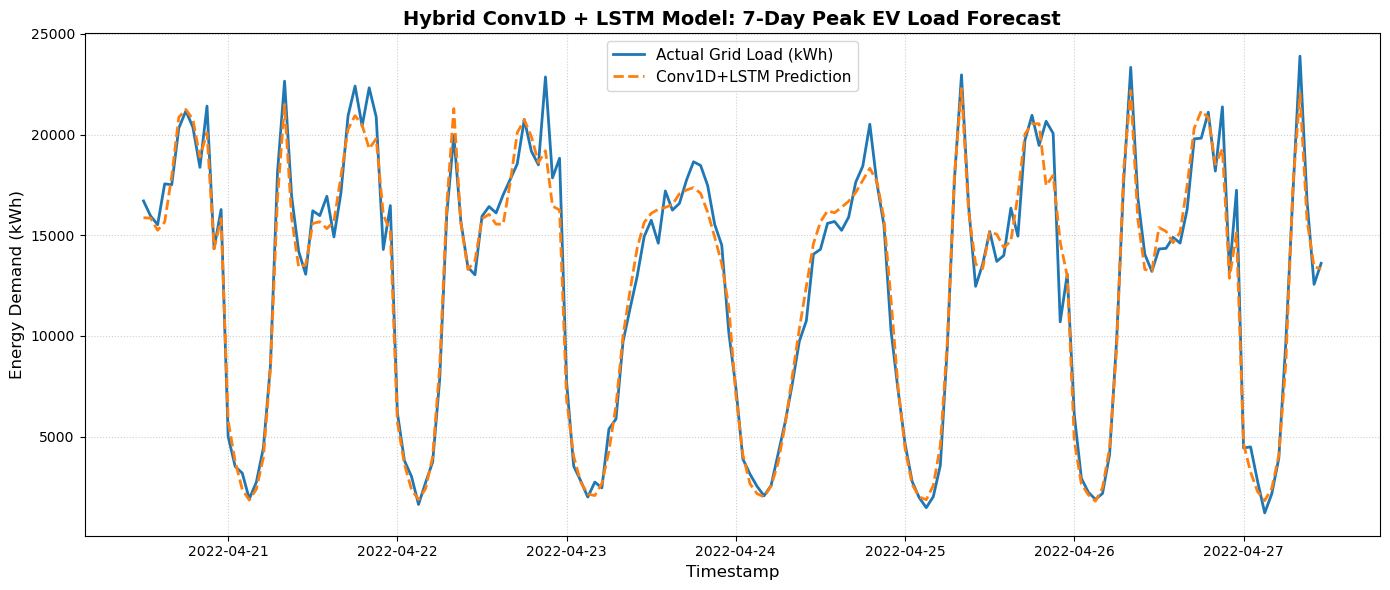

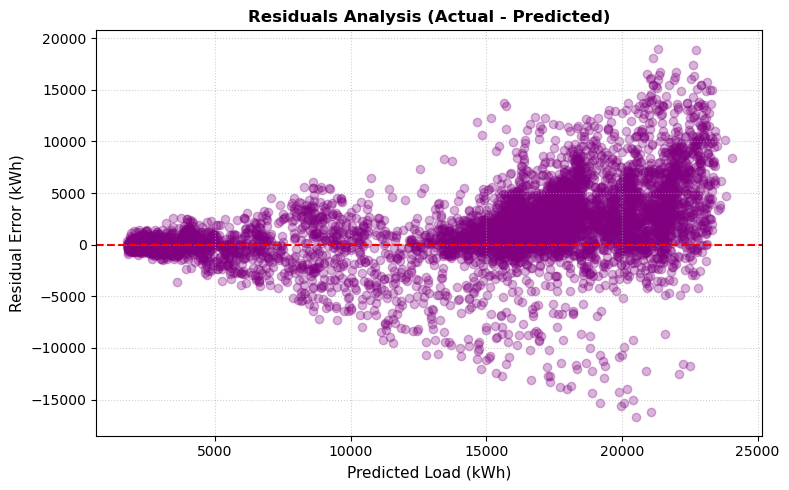

In [2]:
import matplotlib.pyplot as plt

# 1. Plot Actual vs Predicted EV Demand over a 7-day test window (168 hours)
sample_hours = 168  # 1 week of hourly predictions
time_axis = df_test['timestamp'].iloc[SEQ_LEN : SEQ_LEN + sample_hours]

plt.figure(figsize=(14, 6))
plt.plot(time_axis, actuals_kwh[:sample_hours], label='Actual Grid Load (kWh)', color='#1f77b4', linewidth=2)
plt.plot(time_axis, preds_kwh[:sample_hours], label='Conv1D+LSTM Prediction', color='#ff7f0e', linestyle='--', linewidth=2)

plt.title('Hybrid Conv1D + LSTM Model: 7-Day Peak EV Load Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('Energy Demand (kWh)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# 2. Residual Scatter Plot
residuals = actuals_kwh.flatten() - preds_kwh.flatten()

plt.figure(figsize=(8, 5))
plt.scatter(preds_kwh, residuals, alpha=0.3, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals Analysis (Actual - Predicted)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Load (kWh)', fontsize=11)
plt.ylabel('Residual Error (kWh)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()